In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, json, warnings
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import Counter

# Suppress scipy sparse format warnings (harmless internal conversions during expm)
warnings.filterwarnings('ignore', category=Warning, module='scipy.sparse')

from src.core import MultiEdgeGraph, MatchingDecomposition, PauliDecomposition
from src.utils.circuit.exact_evolution import get_exact_evolution_operator
from qiskit import transpile
from qiskit.quantum_info import Operator

In [2]:
# Load precomputed molecular edges (generated by gen_molecular_edges.py via PySCF in WSL)
with open('molecular_edges.json', 'r') as f:
    molecular_data = json.load(f)

print('Loaded molecular edge data:')
print(f'{"Molecule":45s} {"Qubits":>6} {"Edges":>6}')
print('=' * 60)
for key, val in molecular_data.items():
    print(f"{val['title']:45s} {val['nq']:6d} {len(val['edges']):6d}")

Loaded molecular edge data:
Molecule                                      Qubits  Edges
Li3 Triangle (3 active, STO-3G)                    3      6
H2O (3 active, STO-3G)                             3      6
H2O (4 active, STO-3G)                             4     12
BH3 (3 active, STO-3G)                             3      2
BH3 (4 active, STO-3G)                             4      4
NH3 (3 active, STO-3G)                             3      2
NH3 (4 active, STO-3G)                             4      4
H3+ Triangle (3 orb, STO-3G)                       3      2
H4 Square (4 orb, STO-3G)                          4      4
LiH (3 active, STO-3G)                             3      2
LiH (4 active, STO-3G)                             4      4
CH4 (5 active, STO-3G)                             5     66


In [3]:
# Output directory
os.makedirs('molecular_plots', exist_ok=True)

# Global storage
mol_gate_count_data = []

# Visualization colors
ATOM_COLORS = {'H': '#FFFFFF', 'Li': '#CC80FF', 'B': '#FFB5B5', 'C': '#909090',
               'N': '#3050F8', 'O': '#FF0D0D'}
ATOM_SIZES = {'H': 350, 'Li': 500, 'B': 450, 'C': 500, 'N': 450, 'O': 500}
MATCHING_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


def draw_mol(atoms, coords, bonds, title, output_dir='molecular_plots'):
    """Draw ball-and-stick molecule."""
    fig, ax = plt.subplots(figsize=(5, 5))
    for i, j in bonds:
        ax.plot([coords[i][0], coords[j][0]], [coords[i][1], coords[j][1]],
                'k-', lw=4, zorder=1)
    for atom, (x, y) in zip(atoms, coords):
        ax.scatter(x, y, s=ATOM_SIZES.get(atom, 400), c=ATOM_COLORS.get(atom, '#CCC'),
                   edgecolors='black', lw=2, zorder=2)
        ax.annotate(atom, (x, y), ha='center', va='center', fontsize=14,
                    fontweight='bold', zorder=3)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if output_dir:
        safe = title.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('+', 'p').replace('\u2083', '3').replace('\u2082', '2').replace('\u2084', '4')
        fig.savefig(f'{output_dir}/{safe}_molecule.pdf', bbox_inches='tight', dpi=150)
    plt.show()


def draw_graph_and_matchings(edges, title, output_dir='molecular_plots'):
    """Draw interaction graph with edges colored by matching assignment.
    Node size and font scale with qubit count to keep labels readable."""
    n_q = len(list(edges)[0][0])
    G = MultiEdgeGraph(edges)
    comp = MatchingDecomposition(G, heuristic='compression_aware', n_trials=30)
    matchings = comp.get_matchings()

    nxG = nx.Graph()
    for z1, z2 in edges: nxG.add_edge(z1, z2)
    for i in range(2**n_q): nxG.add_node(format(i, f'0{n_q}b'))

    n_nodes = 2**n_q
    if n_nodes <= 8:
        figsize, node_size, font_size, k = (8, 8), 500, 10, 2.0
    elif n_nodes <= 16:
        figsize, node_size, font_size, k = (10, 10), 450, 8, 1.8
    elif n_nodes <= 32:
        figsize, node_size, font_size, k = (13, 13), 400, 6, 1.5
    else:
        figsize, node_size, font_size, k = (16, 16), 350, 5, 1.2

    pos = nx.spring_layout(nxG, seed=42, k=k)
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(nxG, pos, ax=ax, node_size=node_size, node_color='lightblue',
                           edgecolors='black', linewidths=1.2)

    patches = []
    for mi, m in enumerate(matchings):
        c = MATCHING_COLORS[mi % len(MATCHING_COLORS)]
        m_edges = list(m)
        nx.draw_networkx_edges(nxG, pos, edgelist=m_edges, ax=ax,
                               edge_color=c, width=2.5, alpha=0.85)
        masks = set(int(z1, 2) ^ int(z2, 2) for z1, z2 in m_edges)
        if len(masks) == 1:
            mask_bin = format(list(masks)[0], f'0{n_q}b')
            label = f'M{mi}: {len(m_edges)}e [PURE {mask_bin}]'
        else:
            label = f'M{mi}: {len(m_edges)}e [MIXED({len(masks)})]'
        patches.append(mpatches.Patch(color=c, label=label))

    nx.draw_networkx_labels(nxG, pos, ax=ax, font_size=font_size, font_family='monospace')
    ax.legend(handles=patches, fontsize=9, loc='lower left', framealpha=0.9)
    ax.set_title(f'{title}\n({len(edges)} edges, {len(matchings)} matchings)',
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    if output_dir:
        safe = title.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('+', 'p')
        safe = '_'.join(p for p in safe.split('_') if p)
        fig.savefig(f'{output_dir}/{safe}_graph.pdf', bbox_inches='tight', dpi=150)
    plt.show()

    return comp


def analyze_molecule(edges, title, output_dir='molecular_plots', delta_t=0.1):
    """Comp-Aware vs Pauli: gate counts + error convergence."""
    global mol_gate_count_data

    n_steps_list = [1, 2, 5, 10, 20, 50, 100]

    print(f'\n{title}')
    print('=' * 70)

    if len(edges) < 2:
        print(f'Only {len(edges)} edge(s) — too few for meaningful comparison.')
        return

    mask_counts = Counter()
    hamming_counts = Counter()
    for z1, z2 in edges:
        mask = int(z1, 2) ^ int(z2, 2)
        mask_counts[mask] += 1
        hamming_counts[bin(mask).count('1')] += 1
    print(f'Edges: {len(edges)}, XOR masks: {len(mask_counts)}')
    print(f'Hamming distances: {dict(sorted(hamming_counts.items()))}')

    G = MultiEdgeGraph(edges)
    n_q = G.n_qubits
    print(f'Qubits: {n_q}')

    comp_aware_decomp = MatchingDecomposition(G, heuristic='compression_aware', n_trials=30)
    pauli_decomp = PauliDecomposition(G)

    print(f'Compression-Aware Matchings: {comp_aware_decomp.num_matchings()}')

    # List Pauli terms
    pauli_terms = pauli_decomp.pauli_terms
    print(f'\nPauli terms ({len(pauli_terms)}):')
    for term_str, coeff in sorted(pauli_terms, key=lambda x: (len(x[0].replace("I","")), x[0])):
        weight = len(term_str.replace('I', ''))
        print(f'  {coeff:+10.6f} * {term_str}  (weight {weight})')

    exact_operator = get_exact_evolution_operator(delta_t, G.hamiltonian)

    comp_errors, pauli_errors = [], []
    comp_cx, comp_u3, pauli_cx, pauli_u3 = [], [], [], []

    for n_steps in n_steps_list:
        cqc = comp_aware_decomp.build_circuit(n_steps, delta_t)
        tc = transpile(cqc, basis_gates=['u3', 'cx'], optimization_level=3)
        co = Operator(tc)
        comp_cx.append(tc.count_ops().get('cx', 0))
        comp_u3.append(tc.count_ops().get('u3', 0))

        pqc = pauli_decomp.build_circuit(n_steps, delta_t)
        tp = transpile(pqc, basis_gates=['u3', 'cx'], optimization_level=3)
        po = Operator(pqc)
        pauli_cx.append(tp.count_ops().get('cx', 0))
        pauli_u3.append(tp.count_ops().get('u3', 0))

        comp_errors.append(np.linalg.norm(co - exact_operator, ord=2))
        pauli_errors.append(np.linalg.norm(po - exact_operator, ord=2))

    print(f'\nGate Count Summary (U3/CX, transpiled) for {title}:')
    print('=' * 55)
    print(f'{"n_steps":>7} {"Comp-Aware":>15} {"Pauli":>15}')
    for i, ns in enumerate(n_steps_list):
        print(f'{ns:7d} {comp_u3[i]:>6d}/{comp_cx[i]:<6d} {pauli_u3[i]:>6d}/{pauli_cx[i]:<6d}')

    print(f'\n--- CX Summary (n_steps=1) ---')
    print(f'  Comp-Aware:  {comp_cx[0]} CX')
    print(f'  Pauli:       {pauli_cx[0]} CX')
    if pauli_cx[0] > 0:
        pct = (1 - comp_cx[0] / pauli_cx[0]) * 100
        if pct > 0:
            print(f'  Comp-Aware WINS ({pct:+.0f}%)')
        elif pct == 0:
            print(f'  TIE')
        else:
            print(f'  Pauli wins ({pct:+.0f}%)')

    mol_gate_count_data.append({
        'title': title, 'n_qubits': n_q, 'n_edges': G.n_edges,
        'comp_cx': comp_cx[0], 'pauli_cx': pauli_cx[0],
        'n_pauli_terms': len(pauli_terms),
    })

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.loglog(n_steps_list, comp_errors, 'D-',
              label=f'Matching (Comp-Aware, {comp_cx[0]} CX)', linewidth=2.5, markersize=8,
              color='#2ca02c', markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2ca02c')
    ax.loglog(n_steps_list, pauli_errors, 's-',
              label=f'Pauli ({pauli_cx[0]} CX)', linewidth=2.5, markersize=8,
              color='#d62728', markerfacecolor='white', markeredgewidth=2, markeredgecolor='#d62728')
    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact)', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
    safe = title.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('+', 'p')
    safe = '_'.join([p for p in safe.split('_') if p])
    fig.savefig(f'{output_dir}/{safe}_error_analysis.pdf', format='pdf', dpi=300, bbox_inches='tight')
    print(f'Error plot saved as: {output_dir}/{safe}_error_analysis.pdf')
    plt.show()

## Complete Topology
Molecules where all active orbitals have comparable pairwise overlaps, producing a complete interaction graph under JW.
Li₃: 6 edges, 3 XOR masks, 19 Pauli terms. H₃⁺: 2 edges, 1 mask, 11 Pauli terms.

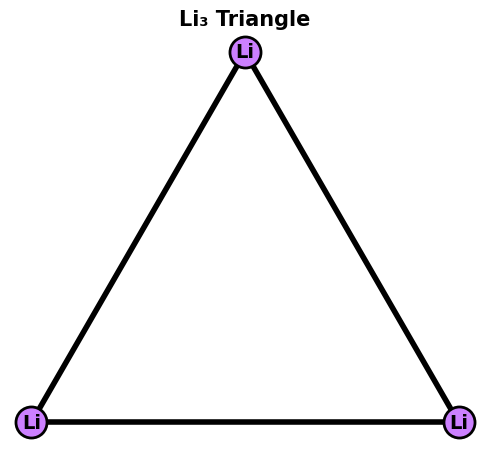

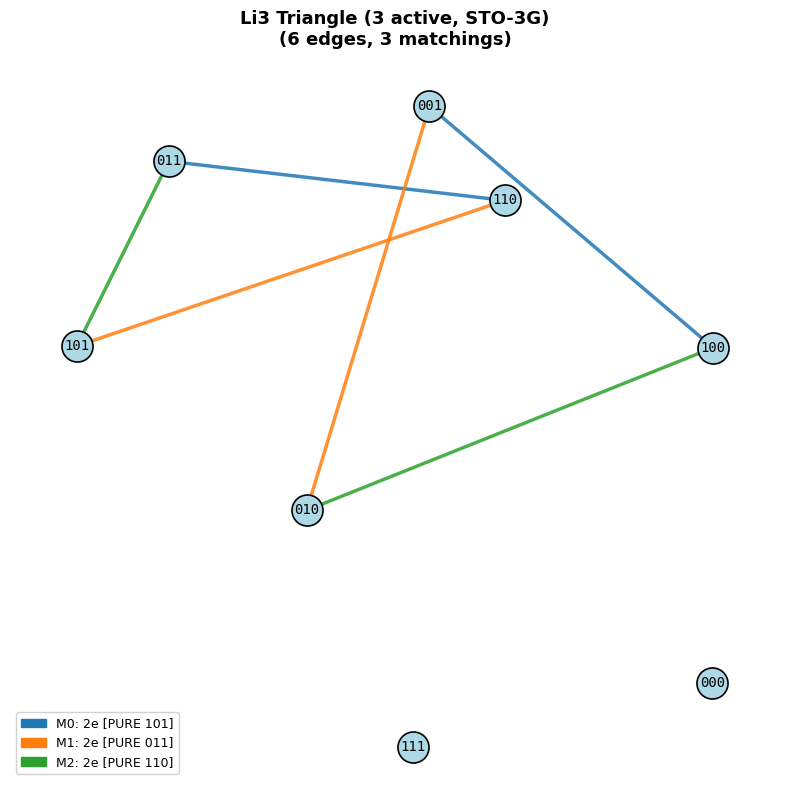


Li3 Triangle (3 active, STO-3G)
Edges: 6, XOR masks: 3
Hamming distances: {2: 6}
Qubits: 3
Compression-Aware Matchings: 3

Pauli terms (6):
   +0.500000 * IXX  (weight 2)
   +0.500000 * IYY  (weight 2)
   +0.500000 * XIX  (weight 2)
   +0.500000 * XXI  (weight 2)
   +0.500000 * YIY  (weight 2)
   +0.500000 * YYI  (weight 2)

Gate Count Summary (U3/CX, transpiled) for Li3 Triangle (3 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1     15/6          17/10    
      2     27/12         31/20    
      5     63/30         73/50    
     10    123/60        143/100   
     20    243/120       283/200   
     50    603/300       703/500   
    100   1203/600      1403/1000  

--- CX Summary (n_steps=1) ---
  Comp-Aware:  6 CX
  Pauli:       10 CX
  Comp-Aware WINS (+40%)
Error plot saved as: molecular_plots/li3_triangle_3_active_sto-3g_error_analysis.pdf


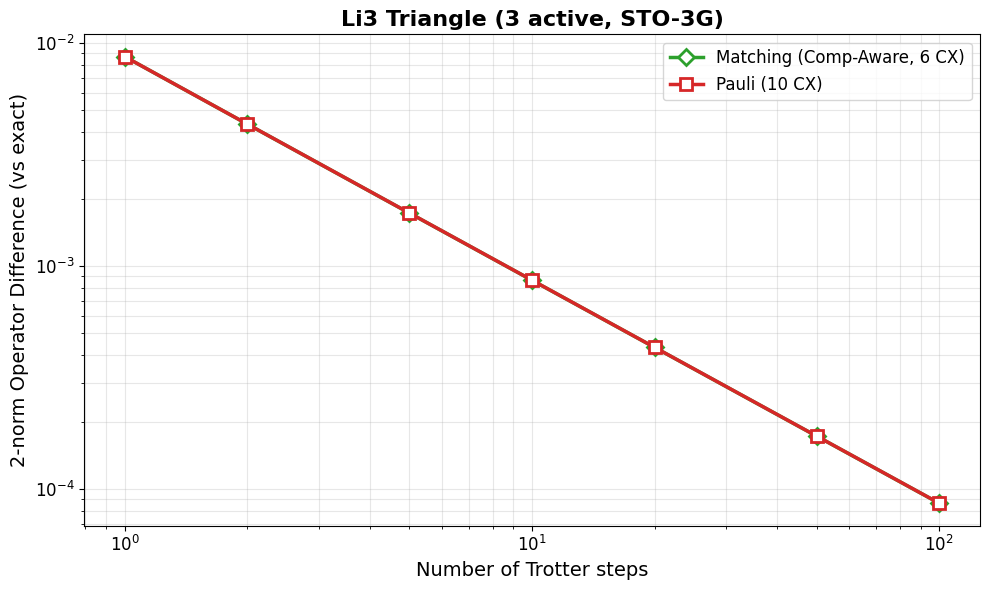

In [4]:
# Li3 — lithium trimer in equilateral triangle geometry
# 3 active valence orbitals (3 frozen core: Li 1s)
# Complete topology: all 3 orbital pairs have comparable overlaps
d = molecular_data["Li3_3orb"]
edges = set(tuple(e) for e in d["edges"])

draw_mol(["Li","Li","Li"], [(0,0),(2.7,0),(1.35,2.34)],
         [(0,1),(1,2),(0,2)], "Li₃ Triangle")
draw_graph_and_matchings(edges, d["title"])
analyze_molecule(edges, d["title"])


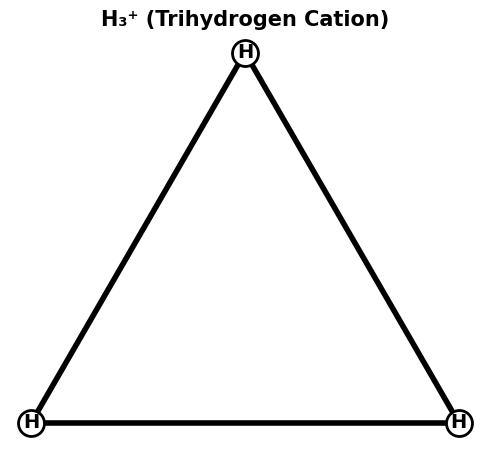

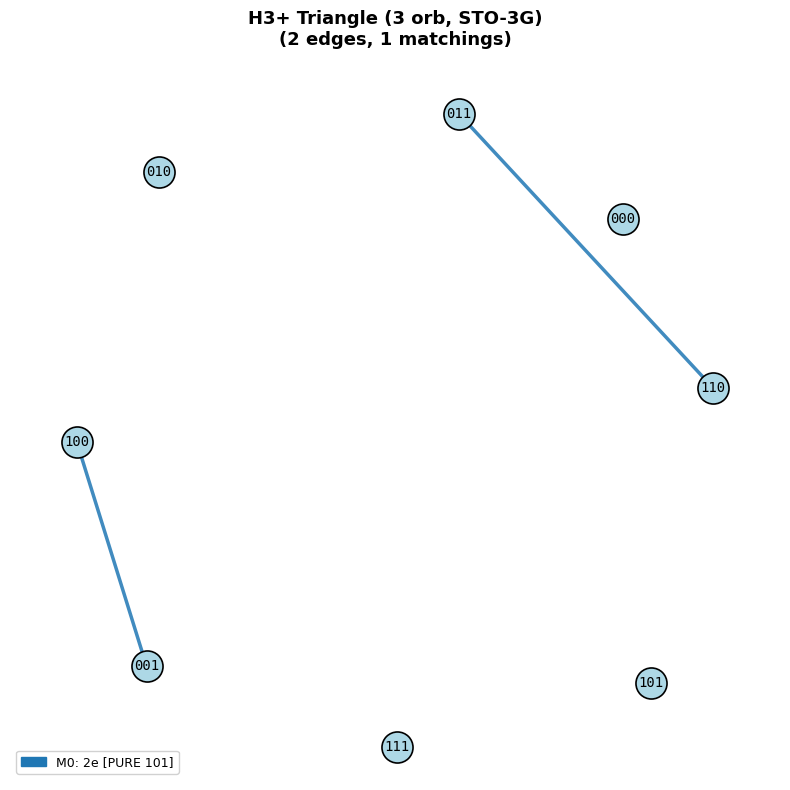


H3+ Triangle (3 orb, STO-3G)
Edges: 2, XOR masks: 1
Hamming distances: {2: 2}
Qubits: 3
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIX  (weight 2)
   +0.500000 * YIY  (weight 2)

Gate Count Summary (U3/CX, transpiled) for H3+ Triangle (3 orb, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/h3p_triangle_3_orb_sto-3g_error_analysis.pdf


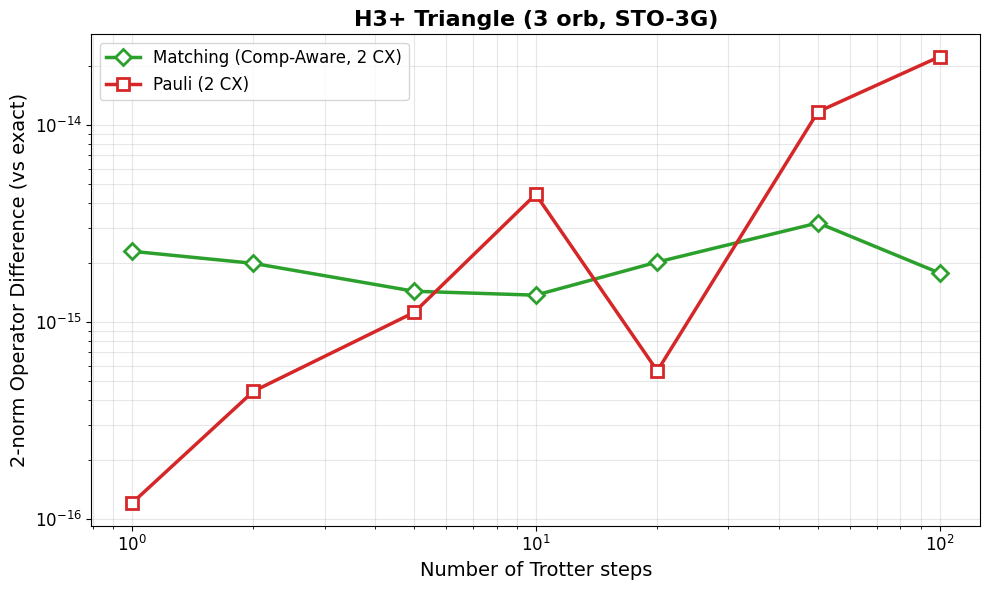

In [5]:
# H3+ — trihydrogen cation, equilateral triangle
# 3 orbitals, all with equal overlap
d = molecular_data["H3p"]
edges = set(tuple(e) for e in d["edges"])

draw_mol(["H","H","H"], [(0,0),(0.87,0),(0.435,0.753)],
         [(0,1),(1,2),(0,2)], "H₃⁺ (Trihydrogen Cation)")
if len(edges) >= 2:
    draw_graph_and_matchings(edges, d["title"])
analyze_molecule(edges, d["title"])

## Bent Topology
Water-like molecules with significant cross-orbital two-body integrals that produce
a dense, uniformly Hamming-2 interaction graph.
H₂O (3 active): 6 edges, 3 masks, 19 Pauli terms. H₂O (4 active): 12 edges, 3 masks, 29 Pauli terms.

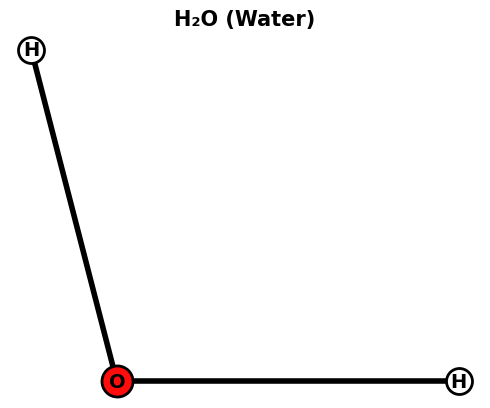

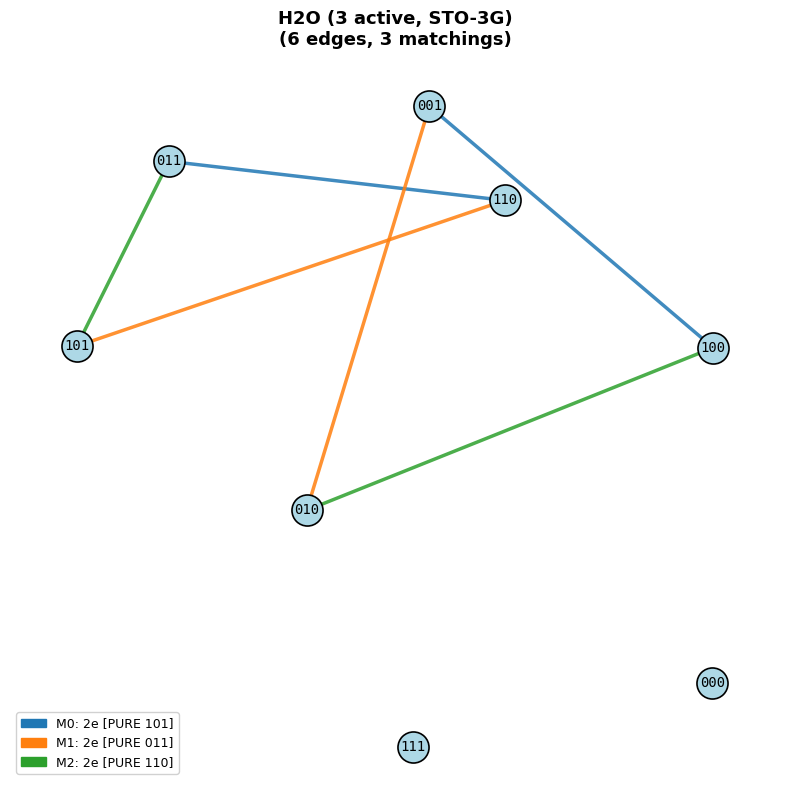


H2O (3 active, STO-3G)
Edges: 6, XOR masks: 3
Hamming distances: {2: 6}
Qubits: 3
Compression-Aware Matchings: 3

Pauli terms (6):
   +0.500000 * IXX  (weight 2)
   +0.500000 * IYY  (weight 2)
   +0.500000 * XIX  (weight 2)
   +0.500000 * XXI  (weight 2)
   +0.500000 * YIY  (weight 2)
   +0.500000 * YYI  (weight 2)

Gate Count Summary (U3/CX, transpiled) for H2O (3 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1     15/6          17/10    
      2     27/12         31/20    
      5     63/30         73/50    
     10    123/60        143/100   
     20    243/120       283/200   
     50    603/300       703/500   
    100   1203/600      1403/1000  

--- CX Summary (n_steps=1) ---
  Comp-Aware:  6 CX
  Pauli:       10 CX
  Comp-Aware WINS (+40%)
Error plot saved as: molecular_plots/h2o_3_active_sto-3g_error_analysis.pdf


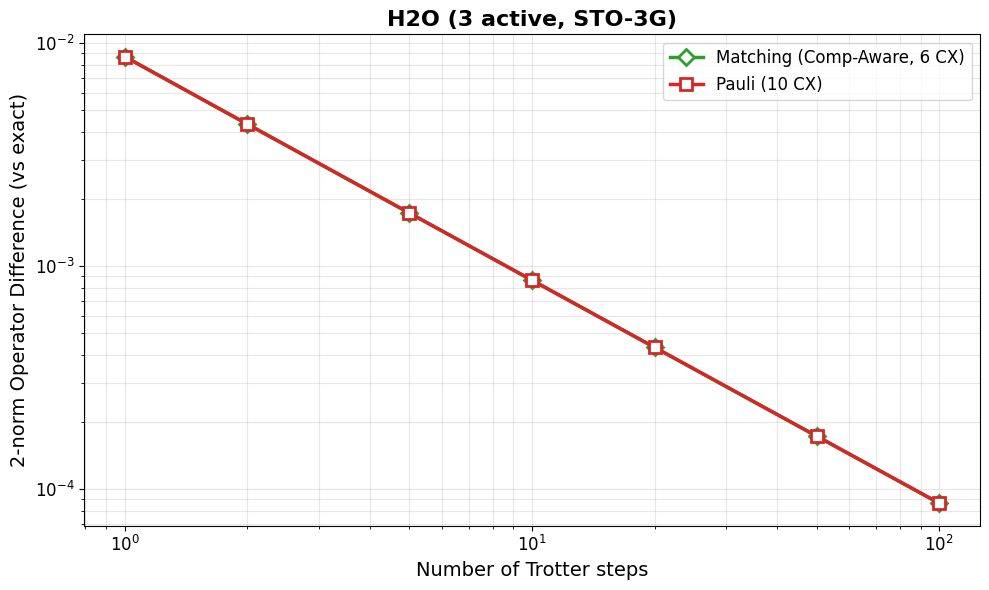

In [6]:
# H2O — water, 3 active orbitals (1 frozen core: O 1s)
# Bent geometry produces 6 edges with 3 XOR masks, all Hamming-2
d = molecular_data["H2O_3orb"]
edges = set(tuple(e) for e in d["edges"])

draw_mol(["O","H","H"], [(0,0),(0.96,0),(-0.24,0.93)],
         [(0,1),(0,2)], "H₂O (Water)")
draw_graph_and_matchings(edges, d["title"])
analyze_molecule(edges, d["title"])


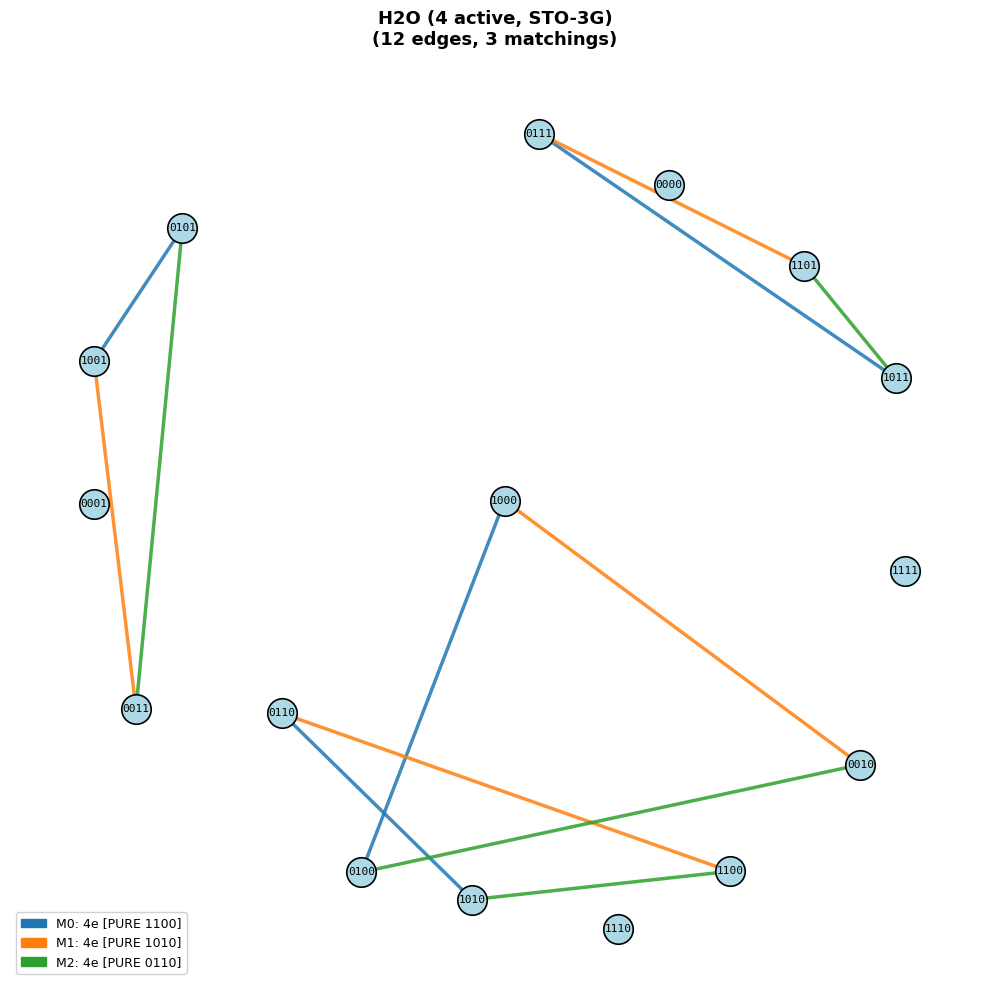


H2O (4 active, STO-3G)
Edges: 12, XOR masks: 3
Hamming distances: {2: 12}
Qubits: 4
Compression-Aware Matchings: 3

Pauli terms (6):
   +0.500000 * IXXI  (weight 2)
   +0.500000 * IYYI  (weight 2)
   +0.500000 * XIXI  (weight 2)
   +0.500000 * XXII  (weight 2)
   +0.500000 * YIYI  (weight 2)
   +0.500000 * YYII  (weight 2)

Gate Count Summary (U3/CX, transpiled) for H2O (4 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1     15/6          17/10    
      2     27/12         31/20    
      5     63/30         73/50    
     10    123/60        143/100   
     20    243/120       283/200   
     50    603/300       703/500   
    100   1203/600      1403/1000  

--- CX Summary (n_steps=1) ---
  Comp-Aware:  6 CX
  Pauli:       10 CX
  Comp-Aware WINS (+40%)
Error plot saved as: molecular_plots/h2o_4_active_sto-3g_error_analysis.pdf


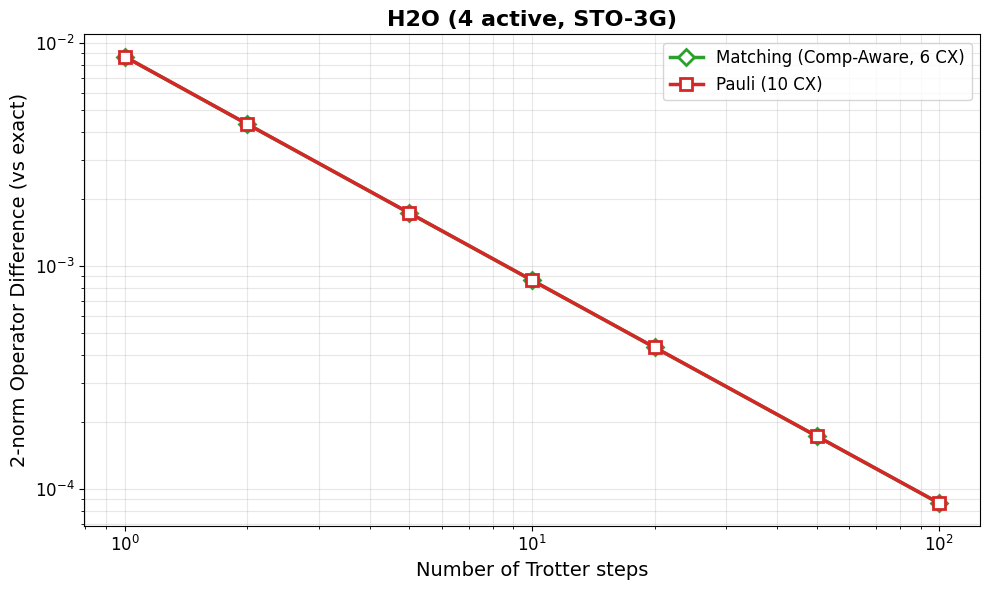

In [7]:
# H2O — 4 active orbitals: graph grows to 12 edges but retains 3 masks
d = molecular_data["H2O_4orb"]
edges = set(tuple(e) for e in d["edges"])

draw_graph_and_matchings(edges, d["title"])
analyze_molecule(edges, d["title"])


## Star Topology
Central atom bonded to peripheral atoms. Real molecular integrals produce very sparse
interaction graphs (2–4 edges), so both methods give minimal circuits.
BH₃: 2–4 edges, 1 mask, 11–17 Pauli terms. NH₃: 2–4 edges, 1 mask, 11–17 Pauli terms.

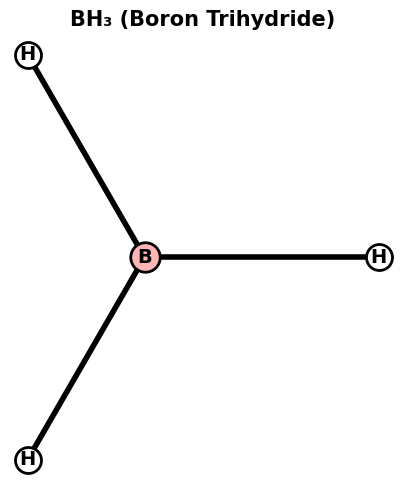

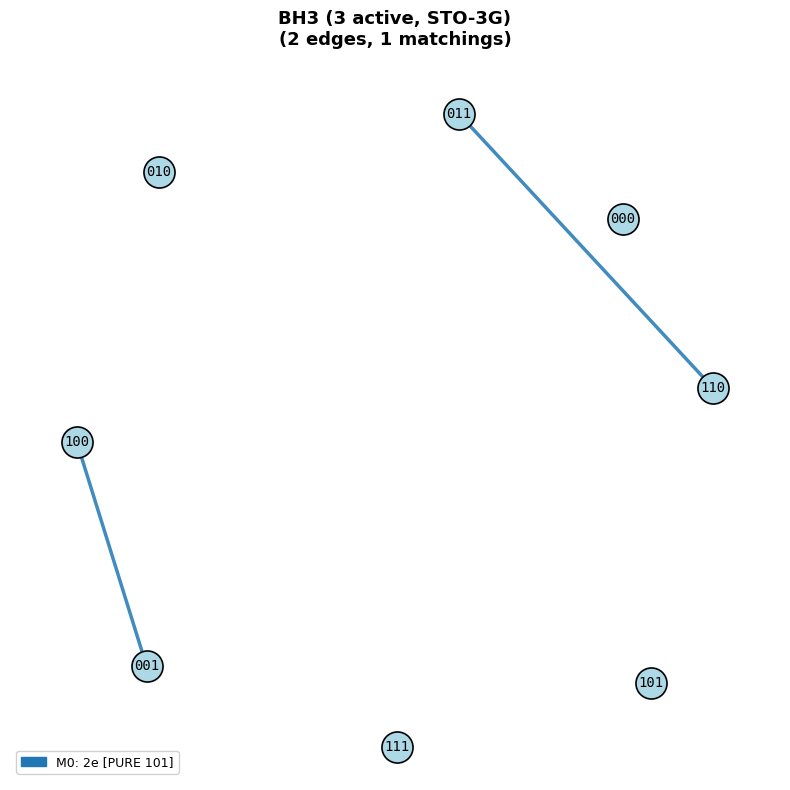


BH3 (3 active, STO-3G)
Edges: 2, XOR masks: 1
Hamming distances: {2: 2}
Qubits: 3
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIX  (weight 2)
   +0.500000 * YIY  (weight 2)

Gate Count Summary (U3/CX, transpiled) for BH3 (3 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/bh3_3_active_sto-3g_error_analysis.pdf


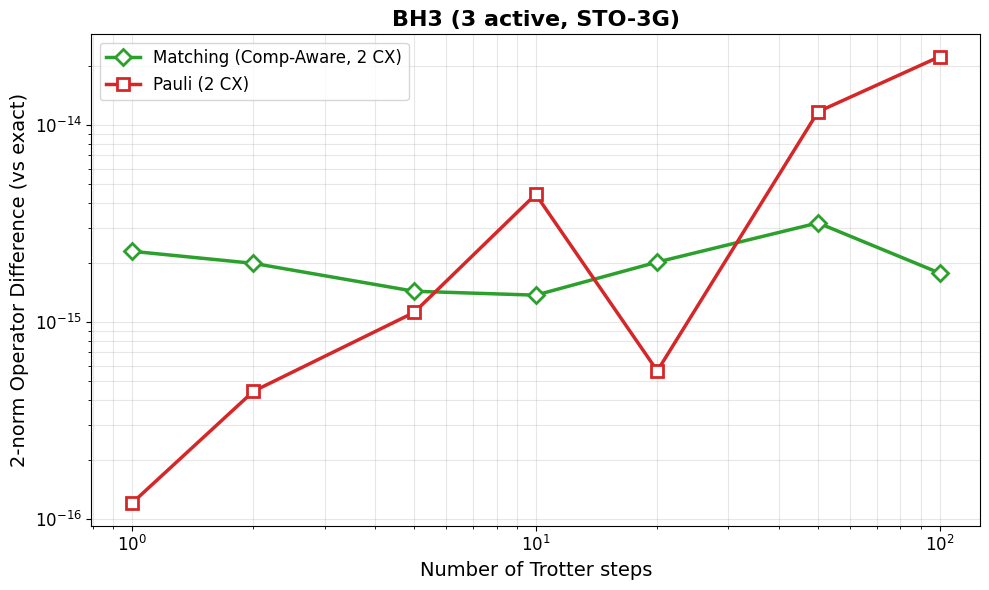

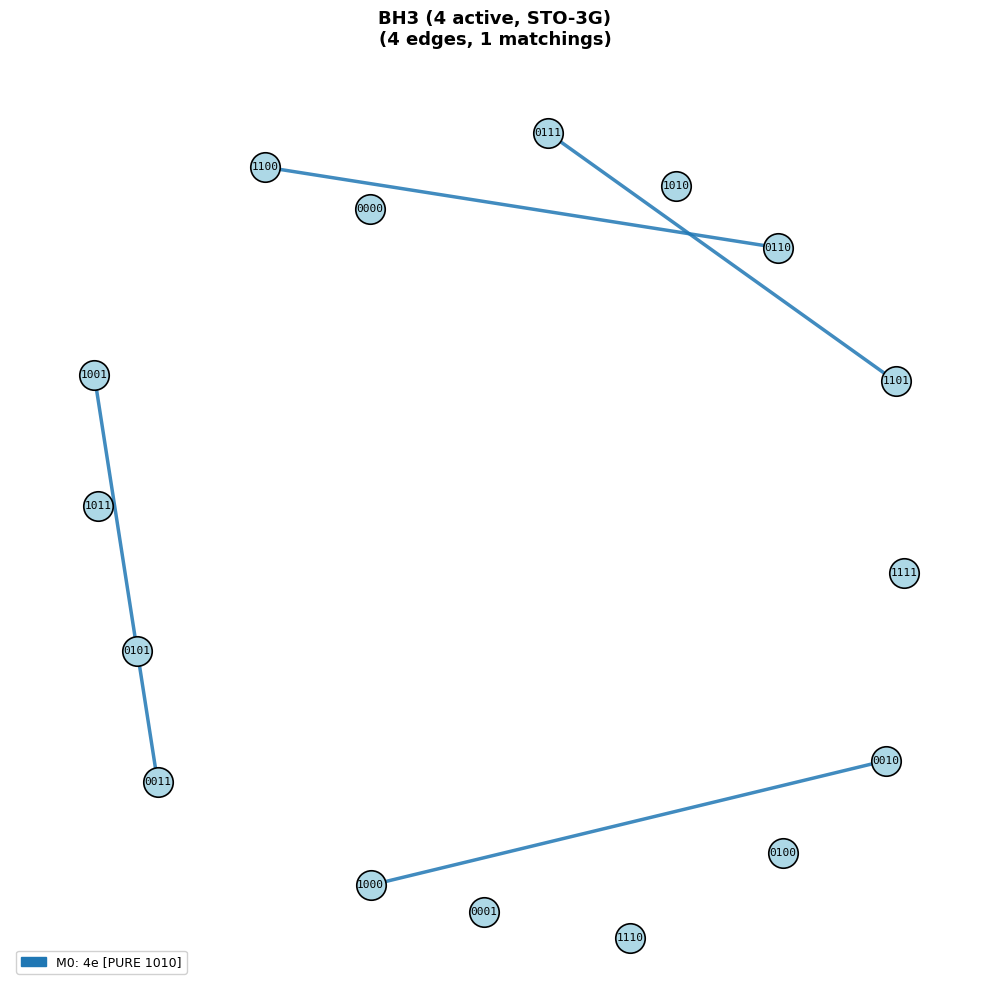


BH3 (4 active, STO-3G)
Edges: 4, XOR masks: 1
Hamming distances: {2: 4}
Qubits: 4
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIXI  (weight 2)
   +0.500000 * YIYI  (weight 2)

Gate Count Summary (U3/CX, transpiled) for BH3 (4 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/bh3_4_active_sto-3g_error_analysis.pdf


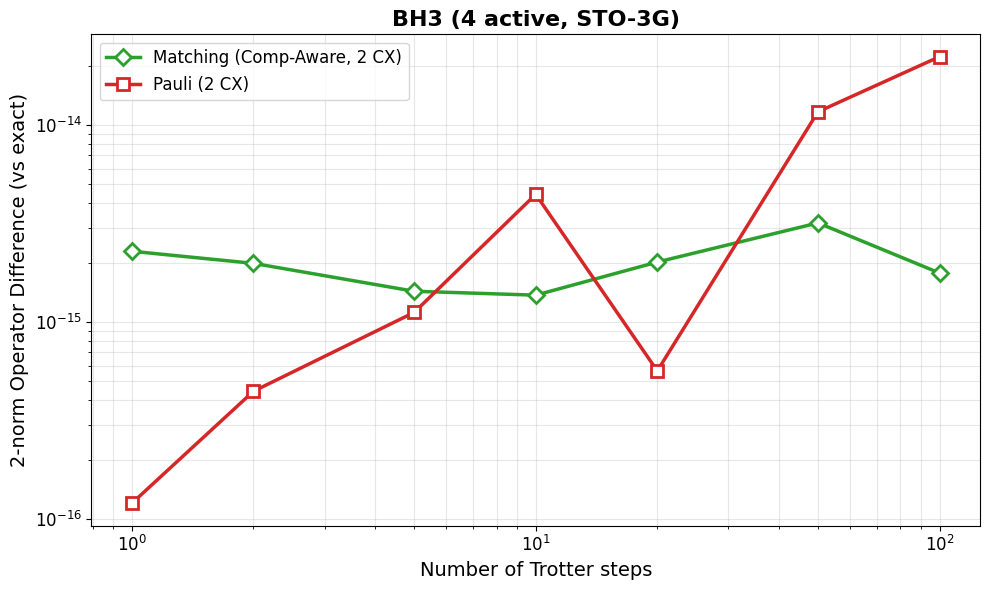

In [8]:
# BH3 — boron trihydride, star topology (B bonded to 3 H)
d3 = molecular_data["BH3_3orb"]
d4 = molecular_data["BH3_4orb"]

draw_mol(["B","H","H","H"], [(0,0),(1.19,0),(-0.595,1.03),(-0.595,-1.03)],
         [(0,1),(0,2),(0,3)], "BH₃ (Boron Trihydride)")

for d in [d3, d4]:
    edges = set(tuple(e) for e in d["edges"])
    if len(edges) >= 2:
        draw_graph_and_matchings(edges, d["title"])
    analyze_molecule(edges, d["title"])

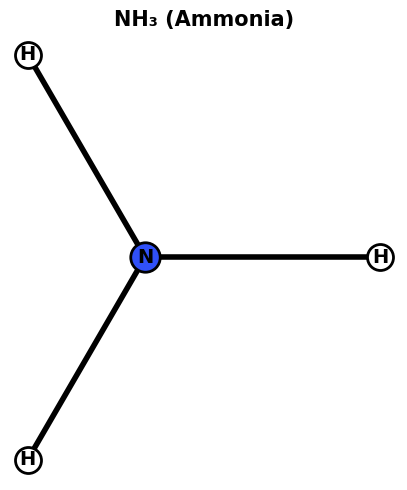

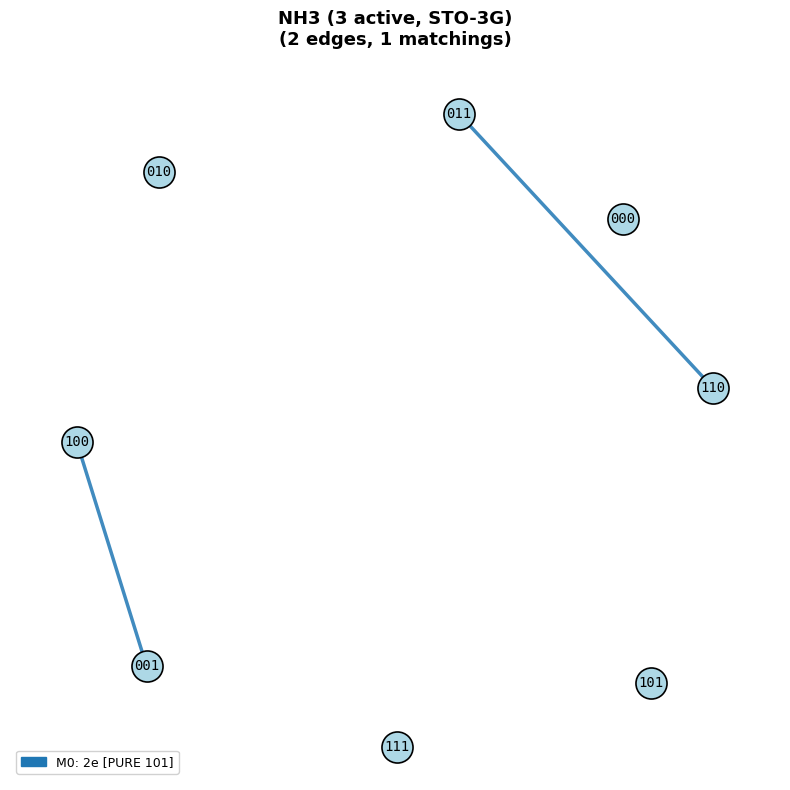


NH3 (3 active, STO-3G)
Edges: 2, XOR masks: 1
Hamming distances: {2: 2}
Qubits: 3
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIX  (weight 2)
   +0.500000 * YIY  (weight 2)

Gate Count Summary (U3/CX, transpiled) for NH3 (3 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/nh3_3_active_sto-3g_error_analysis.pdf


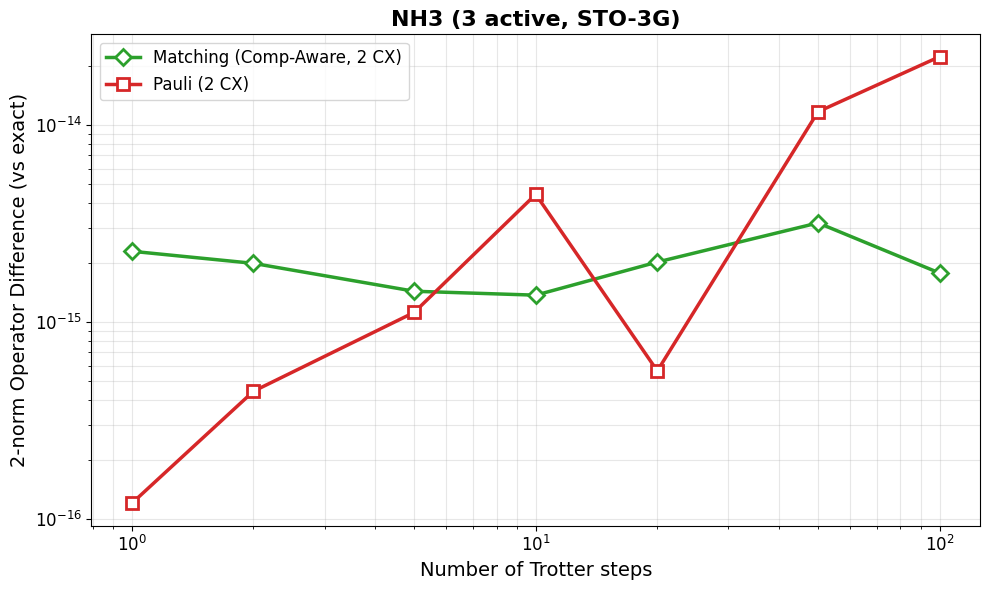

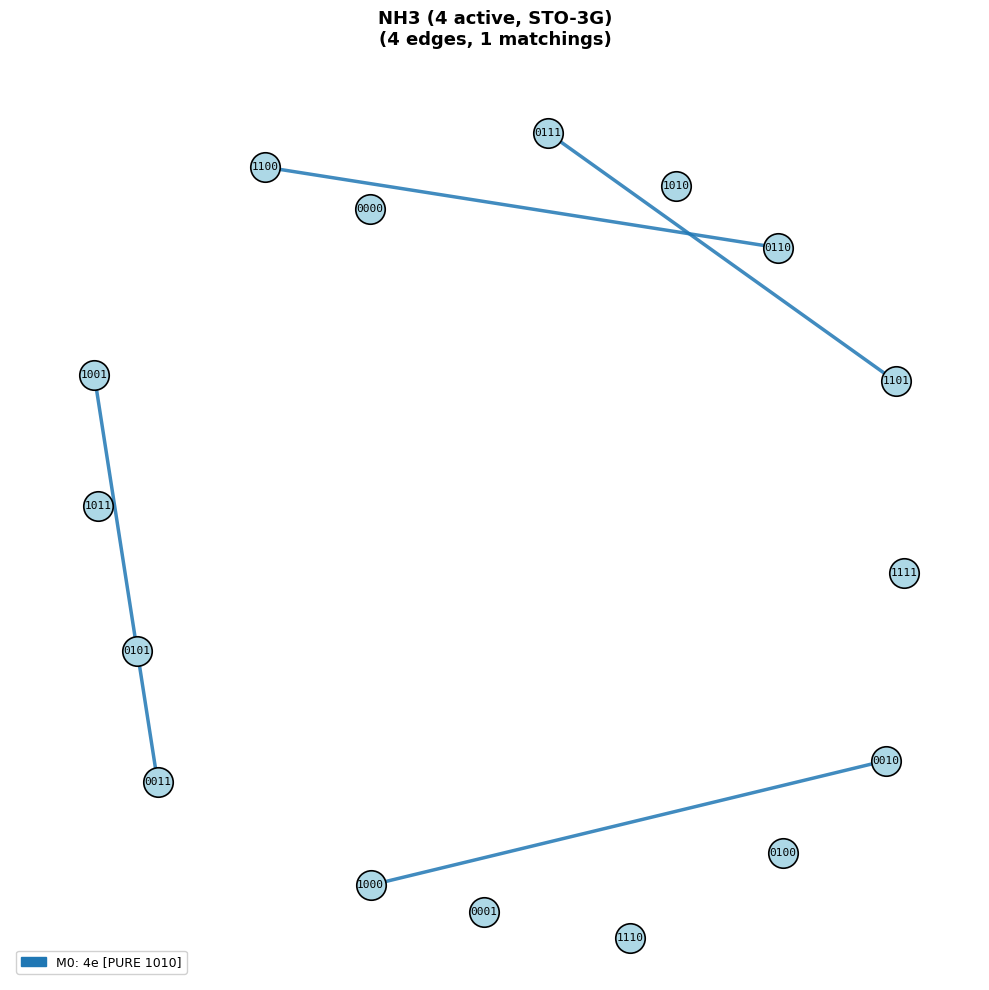


NH3 (4 active, STO-3G)
Edges: 4, XOR masks: 1
Hamming distances: {2: 4}
Qubits: 4
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIXI  (weight 2)
   +0.500000 * YIYI  (weight 2)

Gate Count Summary (U3/CX, transpiled) for NH3 (4 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/nh3_4_active_sto-3g_error_analysis.pdf


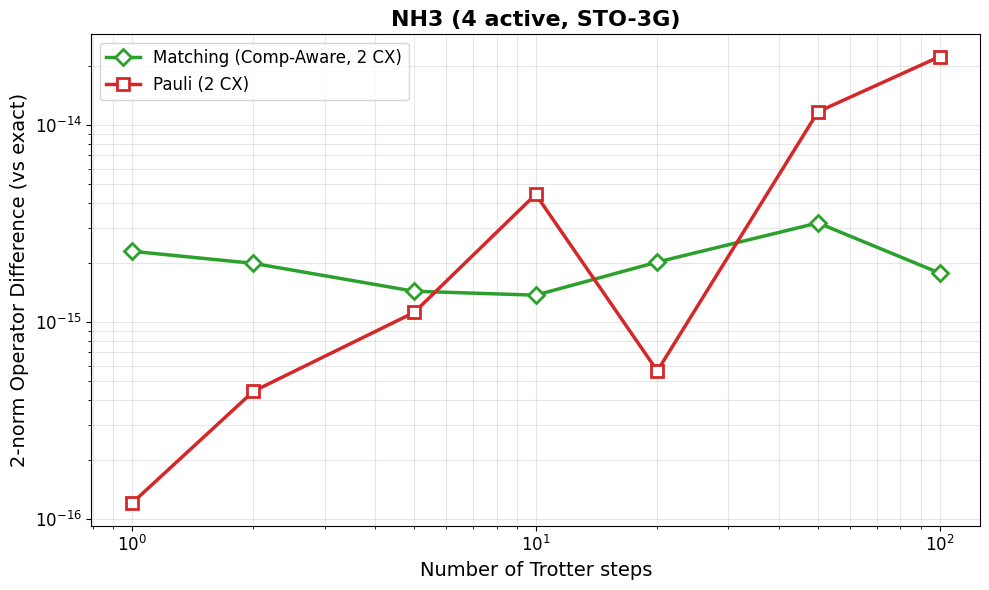

In [9]:
# NH3 — ammonia, star topology (N bonded to 3 H)
d3 = molecular_data["NH3_3orb"]
d4 = molecular_data["NH3_4orb"]

draw_mol(["N","H","H","H"], [(0,0),(0.94,0),(-0.47,0.81),(-0.47,-0.81)],
         [(0,1),(0,2),(0,3)], "NH₃ (Ammonia)")

for d in [d3, d4]:
    edges = set(tuple(e) for e in d["edges"])
    if len(edges) >= 2:
        draw_graph_and_matchings(edges, d["title"])
    analyze_molecule(edges, d["title"])

## Chain Topology
Linear molecules with nearest-neighbor hopping. No Z-string wrapping
(open boundary), so Pauli has no overhead to absorb.
LiH: 2–4 edges, 1 mask, 11–17 Pauli terms.

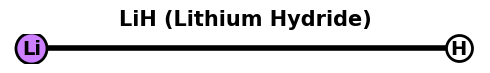

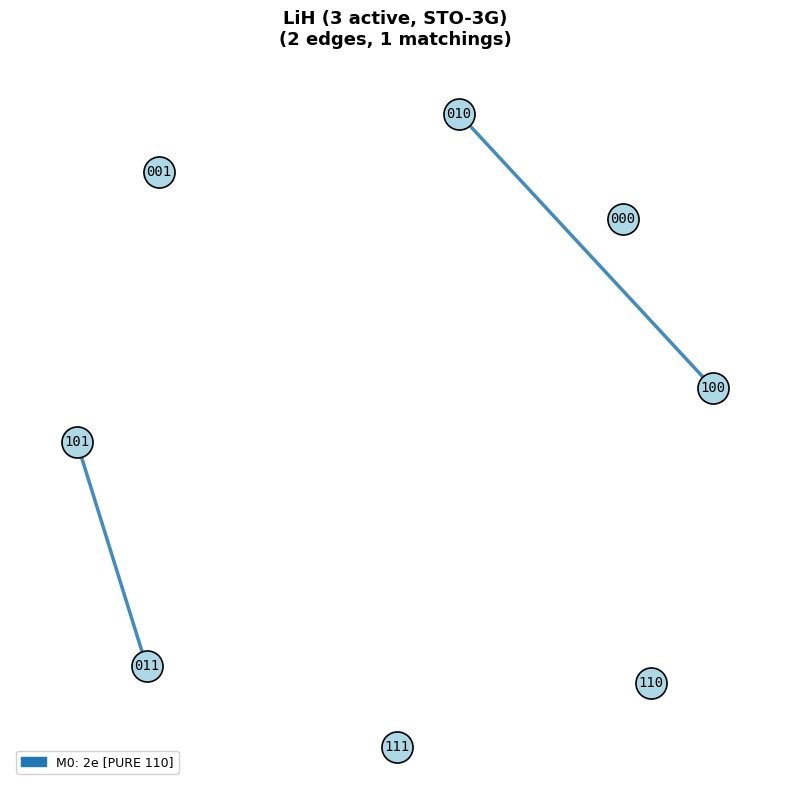


LiH (3 active, STO-3G)
Edges: 2, XOR masks: 1
Hamming distances: {2: 2}
Qubits: 3
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XXI  (weight 2)
   +0.500000 * YYI  (weight 2)

Gate Count Summary (U3/CX, transpiled) for LiH (3 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/lih_3_active_sto-3g_error_analysis.pdf


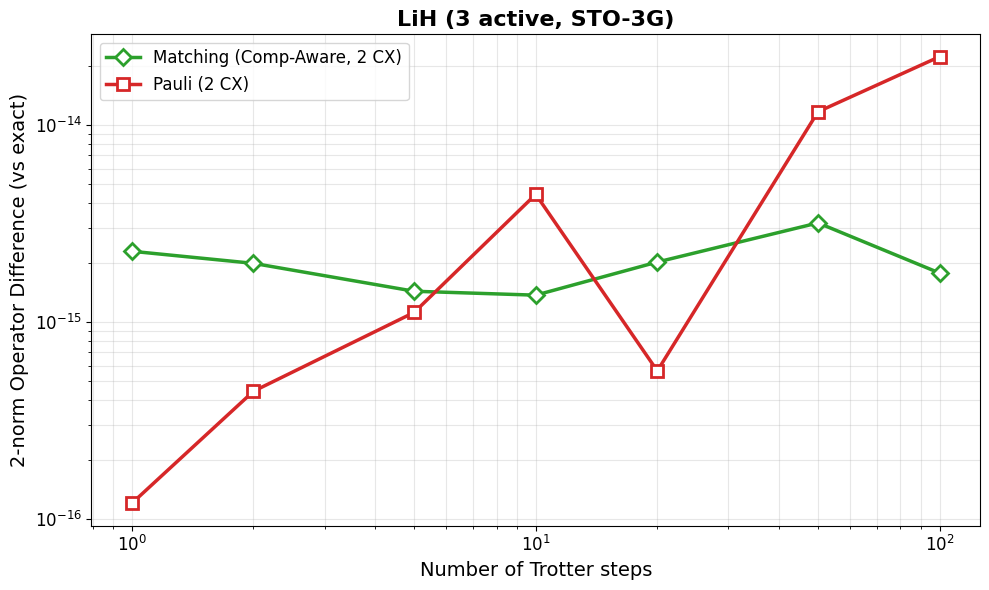

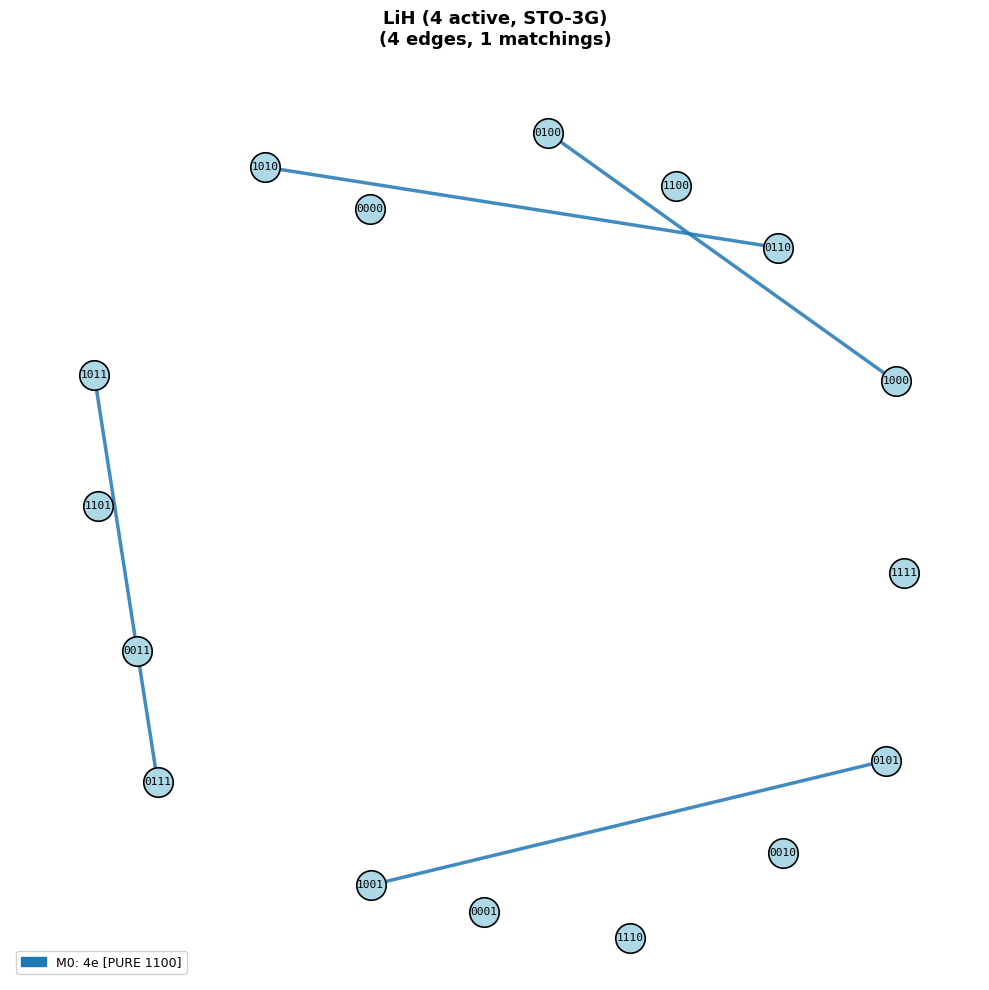


LiH (4 active, STO-3G)
Edges: 4, XOR masks: 1
Hamming distances: {2: 4}
Qubits: 4
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XXII  (weight 2)
   +0.500000 * YYII  (weight 2)

Gate Count Summary (U3/CX, transpiled) for LiH (4 active, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/lih_4_active_sto-3g_error_analysis.pdf


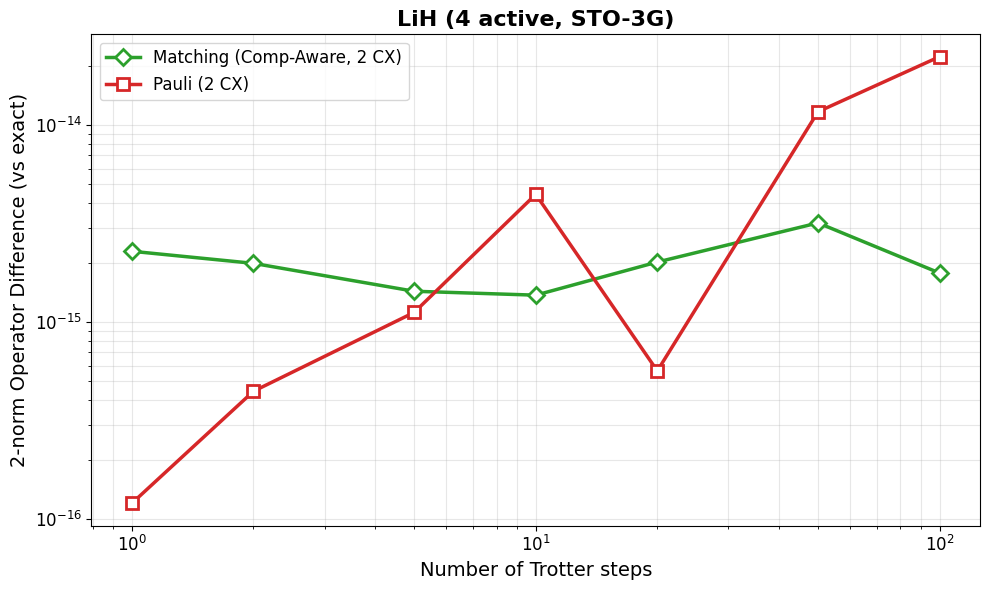

In [10]:
# LiH — lithium hydride, 2-site chain
d3 = molecular_data["LiH_3orb"]
d4 = molecular_data["LiH_4orb"]

draw_mol(["Li","H"], [(0,0),(1.6,0)], [(0,1)], "LiH (Lithium Hydride)")

for d in [d3, d4]:
    edges = set(tuple(e) for e in d["edges"])
    if len(edges) >= 2:
        draw_graph_and_matchings(edges, d["title"])
    analyze_molecule(edges, d["title"])

## Ring Topology
Square planar H4. Real molecular integrals produce fewer edges than the Hubbard model.
H₄: 4 edges, 1 mask, 17 Pauli terms.

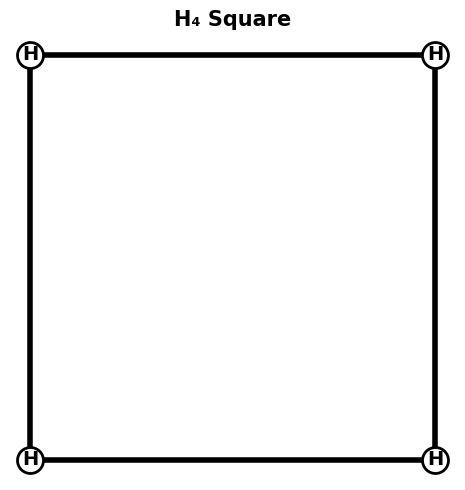

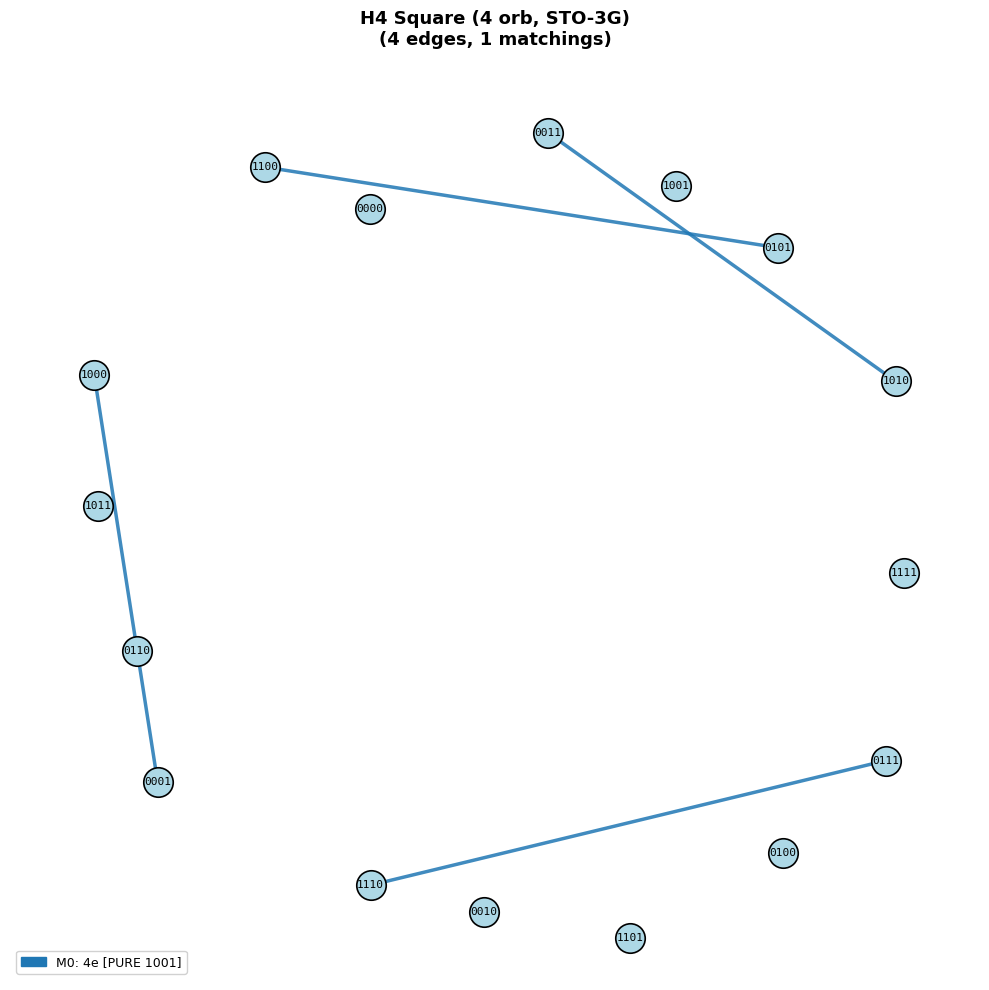


H4 Square (4 orb, STO-3G)
Edges: 4, XOR masks: 1
Hamming distances: {2: 4}
Qubits: 4
Compression-Aware Matchings: 1

Pauli terms (2):
   +0.500000 * XIIX  (weight 2)
   +0.500000 * YIIY  (weight 2)

Gate Count Summary (U3/CX, transpiled) for H4 Square (4 orb, STO-3G):
n_steps      Comp-Aware           Pauli
      1      6/2           6/2     
      2      6/2           6/2     
      5      6/2           6/2     
     10      6/2           6/2     
     20      6/2           6/2     
     50      6/2           6/2     
    100      6/2           6/2     

--- CX Summary (n_steps=1) ---
  Comp-Aware:  2 CX
  Pauli:       2 CX
  TIE
Error plot saved as: molecular_plots/h4_square_4_orb_sto-3g_error_analysis.pdf


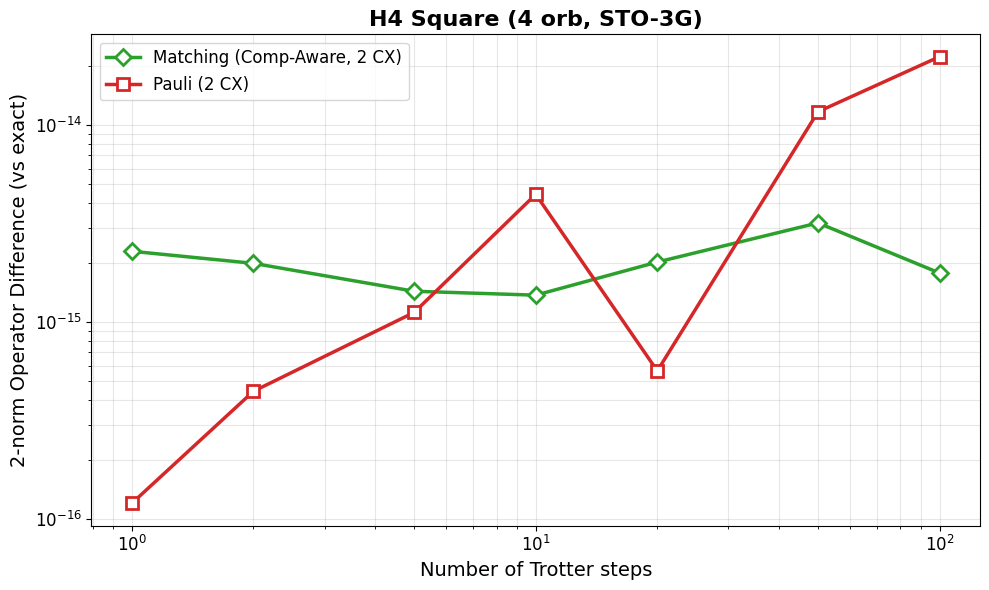

In [11]:
# H4 square — 4 hydrogen atoms in square geometry
d = molecular_data["H4_square"]
edges = set(tuple(e) for e in d["edges"])

draw_mol(["H","H","H","H"], [(0,0),(1,0),(1,1),(0,1)],
         [(0,1),(1,2),(2,3),(3,0)], "H₄ Square")
if len(edges) >= 2:
    draw_graph_and_matchings(edges, d["title"])
analyze_molecule(edges, d["title"])


## Star Topology (Large Active Space)
CH₄ with 5 active orbitals produces a dense interaction graph (66 edges, 13 masks)
with mixed Hamming distances. The multi-controlled gate overhead overwhelms compression.
CH₄: 66 edges, 13 masks, 82 Pauli terms.

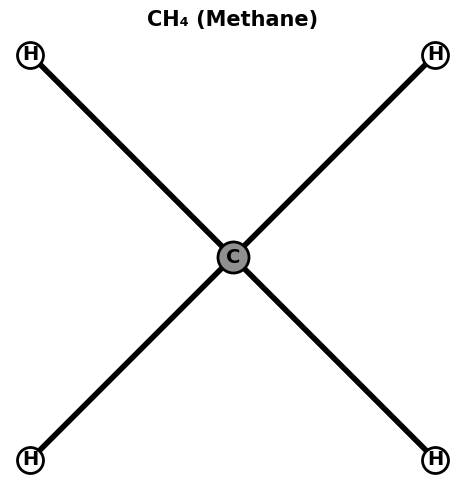


CH4 (5 active, STO-3G)
Edges: 66, XOR masks: 13
Hamming distances: {2: 54, 4: 12}
Qubits: 5
Compression-Aware Matchings: 9

Pauli terms (50):
   +0.500000 * IIIXX  (weight 2)
   +0.500000 * IIIYY  (weight 2)
   +0.500000 * IIXIX  (weight 2)
   +0.250000 * IIXXI  (weight 2)
   +0.500000 * IIYIY  (weight 2)
   +0.250000 * IIYYI  (weight 2)
   +0.500000 * IXIIX  (weight 2)
   +0.250000 * IXIXI  (weight 2)
   +0.250000 * IXXII  (weight 2)
   +0.500000 * IYIIY  (weight 2)
   +0.250000 * IYIYI  (weight 2)
   +0.250000 * IYYII  (weight 2)
   +0.375000 * XIIIX  (weight 2)
   +0.250000 * XIIXI  (weight 2)
   +0.250000 * XIXII  (weight 2)
   +0.250000 * XXIII  (weight 2)
   +0.375000 * YIIIY  (weight 2)
   +0.250000 * YIIYI  (weight 2)
   +0.250000 * YIYII  (weight 2)
   +0.250000 * YYIII  (weight 2)
   -0.250000 * IIXXZ  (weight 3)
   -0.250000 * IIYYZ  (weight 3)
   -0.250000 * IXIXZ  (weight 3)
   -0.250000 * IXXIZ  (weight 3)
   -0.250000 * IYIYZ  (weight 3)
   -0.250000 * IYYIZ  (weight 3)

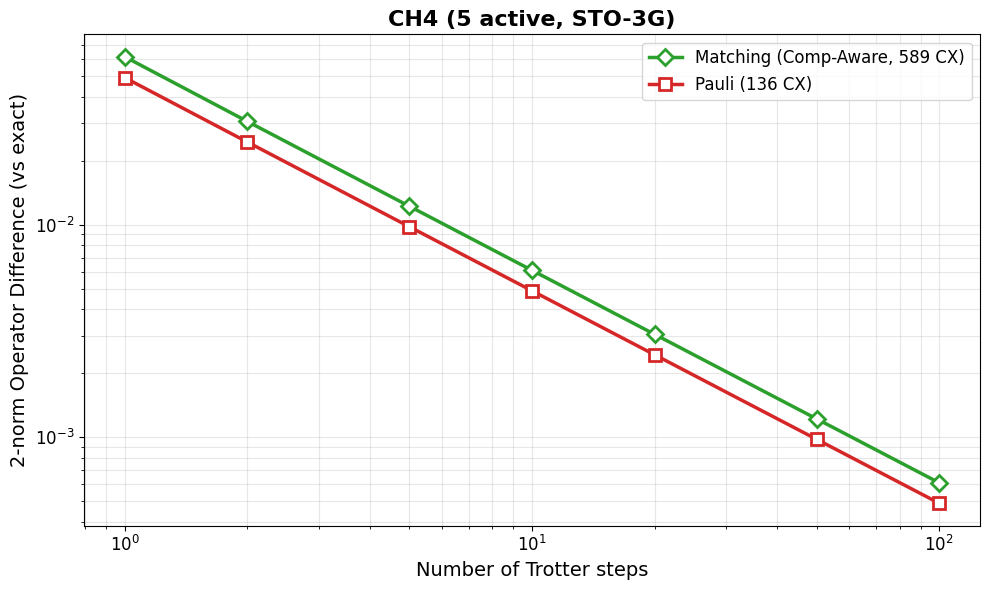

In [12]:
# CH4 — methane, 5 active orbitals (1 frozen core: C 1s)
# Dense interaction graph with mixed Hamming distances
d = molecular_data["CH4_5orb"]
edges = set(tuple(e) for e in d["edges"])

draw_mol(["C","H","H","H","H"], [(0,0),(0.9,0.9),(0.9,-0.9),(-0.9,0.9),(-0.9,-0.9)],
         [(0,1),(0,2),(0,3),(0,4)], "CH₄ (Methane)")
analyze_molecule(edges, d["title"])


## Summary

In [13]:
print(f'{"Molecule":45s} {"nq":>3} {"E":>5} {"P":>4} | {"Comp":>5} {"Pauli":>5} | {"Winner":>6} {"pct":>7}')
print('=' * 90)

wins, ties, losses = 0, 0, 0
for row in mol_gate_count_data:
    c = row["comp_cx"]
    p = row["pauli_cx"]
    n_p = row.get("n_pauli_terms", "?")
    if c < p:
        winner = "COMP"
        wins += 1
    elif c == p:
        winner = "TIE"
        ties += 1
    else:
        winner = "PAULI"
        losses += 1
    pct = f'{(1-c/p)*100:+.0f}%' if p > 0 else "---"
    tag = "***" if c < p else "   "
    print(f"{tag}{row['title']:42s} {row['n_qubits']:3d} {row['n_edges']:5d} {n_p:>4} | {c:5d} {p:5d} | {winner:>6} {pct:>7}")

print(f'\nComp-Aware wins: {wins}  |  TIE: {ties}  |  Pauli wins: {losses}')

Molecule                                       nq     E    P |  Comp Pauli | Winner     pct
***Li3 Triangle (3 active, STO-3G)              3     6    6 |     6    10 |   COMP    +40%
   H3+ Triangle (3 orb, STO-3G)                 3     2    2 |     2     2 |    TIE     +0%
***H2O (3 active, STO-3G)                       3     6    6 |     6    10 |   COMP    +40%
***H2O (4 active, STO-3G)                       4    12    6 |     6    10 |   COMP    +40%
   BH3 (3 active, STO-3G)                       3     2    2 |     2     2 |    TIE     +0%
   BH3 (4 active, STO-3G)                       4     4    2 |     2     2 |    TIE     +0%
   NH3 (3 active, STO-3G)                       3     2    2 |     2     2 |    TIE     +0%
   NH3 (4 active, STO-3G)                       4     4    2 |     2     2 |    TIE     +0%
   LiH (3 active, STO-3G)                       3     2    2 |     2     2 |    TIE     +0%
   LiH (4 active, STO-3G)                       4     4    2 |     2     2 |    